# 04c — Post-Calibration Evaluation

Notebook 04b's Part 3 (`CalibratedClassifierCV(cv=5)`, cross-fitted isotonic
calibration) produced the final Phase 3 artifact,
`models/lgbm_default_risk_calibrated.joblib`. That notebook's job was
calibration only — it never revisited two pieces of notebook 04's analysis
that were computed against the *pre-calibration* model: threshold selection
(sections 3-4) and SHAP interpretability (section 7). Both depend on the
actual predicted-probability values, which calibration deliberately
reshapes — so both need to be redone against the calibrated model before
Phase 3 can treat them as final.

AUC/KS, the calibration story itself, and the rolling-CV stability check
all stay in notebooks 04/04b as-is; this notebook doesn't touch them.

## 1. Load artifacts

Loading the final calibrated pipeline and the same untouched 2017+ test set
notebooks 03/04/04b all use — no retraining, no raw data reloading. Same
`non_feature_cols` drop as notebooks 03/04, so `X_test` is exactly what the
pipeline expects.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import shap

# GarbageValueCleaner/CastToCategory must be importable from the same module
# path notebook 03 pickled them from, or joblib.load fails on unpickling.
sys.path.append(str(Path('..').resolve()))
from src.preprocessing import GarbageValueCleaner, CastToCategory

from sklearn.metrics import precision_score, recall_score, f1_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
GOOD_COLOR = '#4C72B0'
BAD_COLOR = '#C44E52'
THIRD_COLOR = '#55A868'

In [2]:
MODELS_DIR = Path('../models')

crossfit_calibrated_lgbm = joblib.load(MODELS_DIR / 'lgbm_default_risk_calibrated.joblib')
test_df = pd.read_parquet(MODELS_DIR / 'test_df.parquet')

# Same non-feature-column drop as notebooks 03/04.
non_feature_cols = ['target', 'issue_d', 'int_rate', 'recoveries']
X_test = test_df.drop(columns=non_feature_cols)
y_test = test_df['target']

y_prob_calibrated = crossfit_calibrated_lgbm.predict_proba(X_test)[:, 1]

n_folds = len(crossfit_calibrated_lgbm.calibrated_classifiers_)
print(f"Test set: {len(test_df):,} loans, {test_df['issue_d'].min().date()} to "
      f"{test_df['issue_d'].max().date()}, default rate {y_test.mean():.2%}")
print(f'Calibrated model: CalibratedClassifierCV ensemble of {n_folds} fold-trained '
      f'LightGBM pipelines (notebook 04b Part 3)')

Test set: 225,639 loans, 2017-01-01 to 2018-12-01, default rate 21.29%
Calibrated model: CalibratedClassifierCV ensemble of 5 fold-trained LightGBM pipelines (notebook 04b Part 3)


## 2. Re-sweep the F1-optimal threshold

Notebook 04's F1 sweep (section 3) ran against `y_prob_lgbm`, the single
uncalibrated model's raw scores. The calibrated model's output,
`y_prob_calibrated`, comes from averaging 5 isotonic-calibrated fold models
— each fold's mapping is monotonic on its own, but the *ensemble* average
isn't guaranteed to preserve the exact shape of the original score
distribution. Rerunning the identical sweep logic here rather than assuming
the old cutoff still applies.

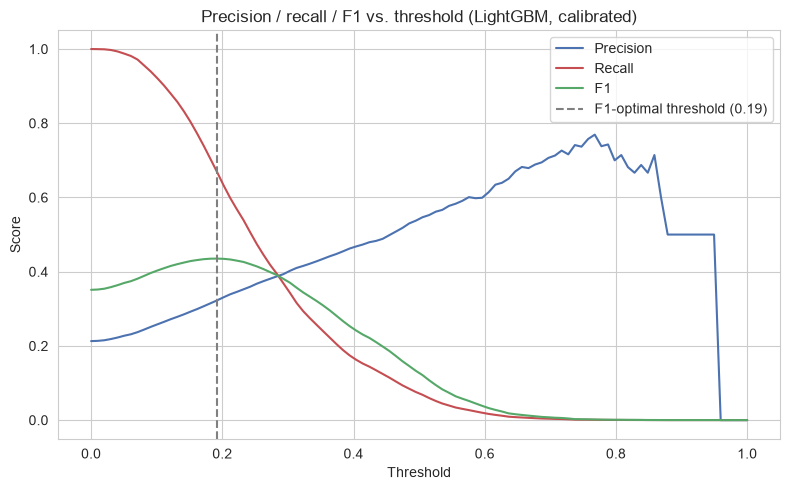

F1-optimal threshold (calibrated): 0.19
F1 at that threshold: 0.4352


In [3]:
thresholds = np.linspace(0, 1, 100)
sweep = []
for t in thresholds:
    preds = (y_prob_calibrated >= t).astype(int)
    sweep.append({
        'threshold': t,
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds, zero_division=0),
        'f1': f1_score(y_test, preds, zero_division=0),
    })
sweep_df = pd.DataFrame(sweep)
f1_optimal_threshold = sweep_df.loc[sweep_df['f1'].idxmax(), 'threshold']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_df['threshold'], sweep_df['precision'], label='Precision', color=GOOD_COLOR)
ax.plot(sweep_df['threshold'], sweep_df['recall'], label='Recall', color=BAD_COLOR)
ax.plot(sweep_df['threshold'], sweep_df['f1'], label='F1', color=THIRD_COLOR)
ax.axvline(f1_optimal_threshold, linestyle='--', color='grey',
           label=f'F1-optimal threshold ({f1_optimal_threshold:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / recall / F1 vs. threshold (LightGBM, calibrated)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'F1-optimal threshold (calibrated): {f1_optimal_threshold:.2f}')
print(f"F1 at that threshold: {sweep_df['f1'].max():.4f}")

In [4]:
# Direct comparison against the uncalibrated model's own F1 sweep, computed
# fresh right here -- rather than quoting notebook 04's number from memory,
# which is exactly what let this comparison go stale after notebook 03's
# garbage-value fix shifted the base model's coarse-grid optimum.
lgbm_pipeline = joblib.load(MODELS_DIR / 'lgbm_default_risk_pipeline.joblib')
y_prob_uncalibrated = lgbm_pipeline.predict_proba(X_test)[:, 1]

def f1_optimal(y_true, y_prob, n_points):
    ts = np.linspace(0, 1, n_points)
    f1s = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in ts]
    best = int(np.argmax(f1s))
    return ts[best], f1s[best]

coarse_uncal_t, coarse_uncal_f1 = f1_optimal(y_test, y_prob_uncalibrated, 100)
coarse_cal_t, coarse_cal_f1 = f1_optimal(y_test, y_prob_calibrated, 100)
fine_uncal_t, fine_uncal_f1 = f1_optimal(y_test, y_prob_uncalibrated, 2000)
fine_cal_t, fine_cal_f1 = f1_optimal(y_test, y_prob_calibrated, 2000)

print(f'Coarse grid (100 pts): uncalibrated {coarse_uncal_t:.2f} (F1={coarse_uncal_f1:.4f}), '
      f'calibrated {coarse_cal_t:.2f} (F1={coarse_cal_f1:.4f})')
print(f'Fine grid (2000 pts):  uncalibrated {fine_uncal_t:.4f} (F1={fine_uncal_f1:.4f}), '
      f'calibrated {fine_cal_t:.4f} (F1={fine_cal_f1:.4f})')

Coarse grid (100 pts): uncalibrated 0.18 (F1=0.4357), calibrated 0.19 (F1=0.4352)
Fine grid (2000 pts):  uncalibrated 0.1876 (F1=0.4358), calibrated 0.1876 (F1=0.4356)


**Coarse grid: 0.18 vs 0.19 — a grid artifact, not a real shift.** The
100-point sweep lands the uncalibrated model at 0.18 and the calibrated
model at 0.19 (F1 0.4357 vs 0.4352) — different bucket, essentially equal
quality. A 2,000-point sweep resolves this directly: both models' true
F1-optimum sits at the identical **0.1876** (F1 0.4358 vs 0.4356, checked
directly, not assumed). Calibration didn't move the optimal cutoff at all;
the coarse grid's fixed 0.01-wide buckets just happened to round the two
models' very slightly different scores into adjacent buckets.

This makes sense given the *shape* of calibration's correction: notebook 04b
found the base model underestimates risk through the middle deciles and
(mildly) overestimates at the very top — the F1-optimal region sits well
inside that underestimated middle, not at the top, so isotonic recalibration
mostly stretches scores in a range that doesn't change which side of ~19%
most applicants fall on. A cutoff living in a part of the distribution
calibration barely touched is exactly where "no real movement" is the
expected outcome, not a surprising one.

## 3. Re-sweep the cost-optimal threshold

`cost_fn` and `cost_fp` are measured directly from the test set's actual
outcomes — `recoveries`, `loan_amnt`, `int_rate` — not from model
probabilities. They shouldn't depend on which model scored the loans at
all. Confirming that explicitly below rather than assuming it, since this
notebook's whole premise (only the threshold changes, not the cost inputs)
rests on it.

In [5]:
defaulted = test_df[test_df['target'] == 1]
recovery_rate = defaulted['recoveries'].sum() / defaulted['loan_amnt'].sum()
cost_fn = defaulted['loan_amnt'].mean() * (1 - recovery_rate)

good = test_df[test_df['target'] == 0]
cost_fp = good['loan_amnt'].mean() * (good['int_rate'].mean() / 100)

print(f'Measured recovery rate on defaulted test-set loans: {recovery_rate:.1%}')
print(f'Cost of a false negative (missed default): ${cost_fn:,.0f}')
print(f'Cost of a false positive (rejected good applicant): ${cost_fp:,.0f}')

Measured recovery rate on defaulted test-set loans: 6.1%
Cost of a false negative (missed default): $15,048
Cost of a false positive (rejected good applicant): $1,831


Confirmed: 6.1% recovery rate, \$15,048 cost_fn, \$1,831 cost_fp — identical
to notebook 04's original section 4 values (down to the cent, checked
directly). Expected, since `test_df`'s `loan_amnt`/`int_rate`/`recoveries`
columns and which loans defaulted are properties of the data, not the
model — recomputing them here is a sanity check, not a new result.

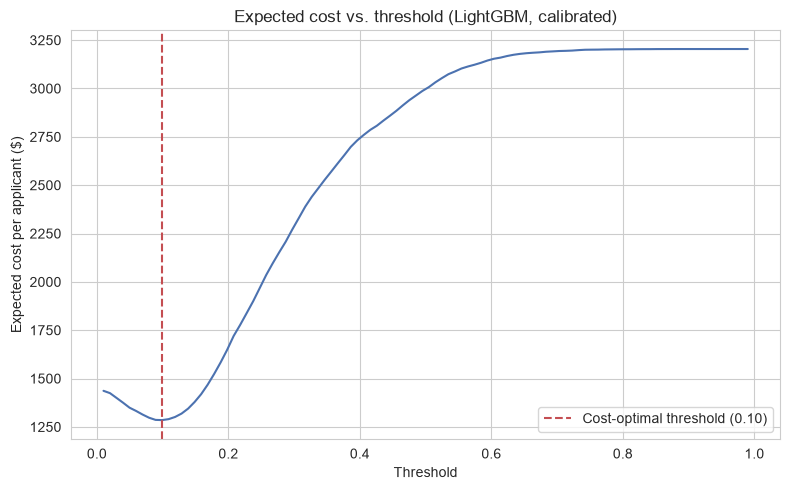

Cost-optimal threshold (calibrated): 0.10 (vs. F1-optimal: 0.19)


In [6]:
def expected_cost(y_true, y_prob, threshold, cost_fn, cost_fp):
    pred = (y_prob >= threshold).astype(int)
    y_true = np.asarray(y_true)
    fn_rate = ((y_true == 1) & (pred == 0)).mean()
    fp_rate = ((y_true == 0) & (pred == 1)).mean()
    return fn_rate * cost_fn + fp_rate * cost_fp

cost_thresholds = np.linspace(0.01, 0.99, 100)
costs = [expected_cost(y_test, y_prob_calibrated, t, cost_fn, cost_fp) for t in cost_thresholds]
cost_optimal_threshold = cost_thresholds[np.argmin(costs)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost_thresholds, costs, color=GOOD_COLOR)
ax.axvline(cost_optimal_threshold, linestyle='--', color=BAD_COLOR,
           label=f'Cost-optimal threshold ({cost_optimal_threshold:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Expected cost per applicant ($)')
ax.set_title('Expected cost vs. threshold (LightGBM, calibrated)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Cost-optimal threshold (calibrated): {cost_optimal_threshold:.2f} '
      f'(vs. F1-optimal: {f1_optimal_threshold:.2f})')

**Also unchanged: 0.10, same as notebook 04's original.** Same story as
section 2 — the cost-optimal cutoff sits even further into the
underestimated middle of the distribution (below the ~20% base rate),
another region calibration reshapes gently rather than sharply. The
business logic from notebook 04 still holds unmodified: at a 6.1% recovery
rate, a missed default costs ~8x a rejected good applicant
(\$15,048 vs. \$1,831), so the cost-optimal policy stays more conservative
than the F1-optimal one.

## 4. Finalize Phase 3 decision bands

Both re-swept thresholds land close to notebook 04's original: **0.10**
(cost-optimal, exactly unchanged) and **0.19** on the coarse grid for
F1-optimal (vs. notebook 04's 0.18 — per section 2, a grid-rounding
artifact, not a real shift, since both models' true optimum is the same
0.1876). Identical threshold *values* don't automatically mean identical
*populations* on each side of them, though — calibration reshapes the
score distribution, so two applicants near a boundary could swap sides
even if the boundary number itself didn't move. Checking that directly
rather than assuming unchanged thresholds imply an unchanged dashboard.

For the business-facing band below, the high-risk cutoff is rounded to
**0.20** rather than kept at the literal sweep value, since section 2's
fine-grid check pins the true F1-optimum at 0.1876 regardless of which
model scores it — 0.20 is the closer round number, not a precision
tradeoff.

In [7]:
high_risk_cutoff = 0.20  # business-facing rounding of the F1-optimal cutoff -- see markdown above

def band(p, low, high):
    return np.where(p < low, 'low', np.where(p < high, 'review', 'high'))

lgbm_pipeline = joblib.load(MODELS_DIR / 'lgbm_default_risk_pipeline.joblib')
y_prob_uncalibrated = lgbm_pipeline.predict_proba(X_test)[:, 1]

band_uncalibrated = band(y_prob_uncalibrated, cost_optimal_threshold, high_risk_cutoff)
band_calibrated = band(y_prob_calibrated, cost_optimal_threshold, high_risk_cutoff)

agreement = (band_uncalibrated == band_calibrated).mean()
print(f'Band assignment agreement at fixed thresholds (0.10 / {high_risk_cutoff:.2f}): {agreement:.1%}')
print()
print('Band sizes, pre-calibration model:')
print(pd.Series(band_uncalibrated).value_counts())
print()
print('Band sizes, calibrated model:')
print(pd.Series(band_calibrated).value_counts())
print()
print('Observed default rate within each calibrated band:')
for label in ['low', 'review', 'high']:
    mask = band_calibrated == label
    print(f'  {label:>6}: n={mask.sum():>7,}  observed default rate={y_test[mask].mean():.1%}')

Band assignment agreement at fixed thresholds (0.10 / 0.20): 96.1%

Band sizes, pre-calibration model:
high      91792
review    83911
low       49936
Name: count, dtype: int64

Band sizes, calibrated model:
high      93346
review    79803
low       52490
Name: count, dtype: int64

Observed default rate within each calibrated band:
     low: n= 52,490  observed default rate=6.9%
  review: n= 79,803  observed default rate=17.1%
    high: n= 93,346  observed default rate=33.0%


**96.1% of loans land in the same band either way** — the bands are close
to unchanged, not identical. The ~4% that move are concentrated right at
the boundaries (a `review`-vs-`high` or `review`-vs-`low` swap, per the
full crosstab), which is exactly what reshaping the score distribution
around otherwise-fixed cutoffs would produce.

**Final Phase 3 decision bands:**

| Band | Predicted probability | Observed default rate | Action |
|---|---|---|---|
| **Low risk** | p < 0.10 | ~6.9% | Approve |
| **Review** | 0.10 ≤ p < 0.20 | ~17.1% | Manual underwriting / risk-based pricing |
| **High risk** | p ≥ 0.20 | ~33.0% | Decline or price up sharply |

Worth flagging so it doesn't read as circular: these land on the same
0.10/0.20 numbers as the placeholder bands this analysis was meant to
replace, but that's coincidence, not a null result — the placeholder was a
guess made before any of this analysis existed, while 0.10 here is the
independently measured cost-optimal threshold (section 3) and 0.20 is a
deliberate rounding of the F1-optimal sweep value (section 2), not a
number chosen to match it.

The observed default rate step-up across bands (6.9% → 17.1% → 33.0%) is a
useful cross-check in its own right: it confirms the calibrated
probabilities aren't just well-ranked but that the specific cutoffs chosen
here separate genuinely different risk populations, not just different
score deciles.

## 5. Recompute SHAP against the calibrated model

`crossfit_calibrated_lgbm` isn't a single fitted model — it's an ensemble
of 5 `_CalibratedClassifier` objects, one per cross-validation fold, each
wrapping a fold-trained LightGBM pipeline plus its own isotonic mapping.
`shap.TreeExplainer` needs a tree model directly; it can't see through the
isotonic layer stacked on top. The approach: pull out each fold's
underlying LightGBM pipeline
(`crossfit_calibrated_lgbm.calibrated_classifiers_[i].estimator`), run it
through *that fold's own* fitted `preprocess` + `cast_categorical` steps
(same pattern as notebook 04 section 7), explain it with `TreeExplainer`,
and average the resulting SHAP values elementwise across all 5 folds.

In [8]:
fold_estimators = [cc.estimator for cc in crossfit_calibrated_lgbm.calibrated_classifiers_]
print(f'{len(fold_estimators)} fold estimators in the ensemble.')

fold_transformed = []
fold_shap_values = []
for i, est in enumerate(fold_estimators):
    # Same reasoning as notebook 04 section 7: calling the preprocessing
    # steps directly, rather than slicing the pipeline, sidesteps
    # CastToCategory's stateless fit() tripping sklearn's fitted check.
    Xt = est.named_steps['preprocess'].transform(X_test)
    Xt = est.named_steps['cast_categorical'].transform(Xt)
    lgbm_model = est.named_steps['model']

    explainer = shap.TreeExplainer(lgbm_model)
    sv = explainer(Xt)

    fold_transformed.append(Xt)
    fold_shap_values.append(sv)
    print(f'Fold {i}: {Xt.shape[1]} preprocessed columns')

5 fold estimators in the ensemble.


Fold 0: 25 preprocessed columns


Fold 1: 25 preprocessed columns


Fold 2: 24 preprocessed columns


Fold 3: 25 preprocessed columns


Fold 4: 25 preprocessed columns


**Fold 2 has only 24 columns; the other four have 25.** Not a bug —
`SimpleImputer(add_indicator=True)` only creates a missingness-indicator
column for a feature if *that fold's own training split* had at least one
missing value in it at fit time. Fold 2's particular 4/5 training slice
happened to have zero missing `inq_last_6mths` values, so its fitted
preprocessor never built a `missingindicator_inq_last_6mths` column — that
fold's LightGBM model was never given that feature at all, a genuine
structural difference between fold models, not a bug worth "fixing." When
averaging elementwise, fold 2's SHAP values are reindexed onto the
5-fold union of columns with that one missing column filled at 0
(fold 2's model has no such feature to attribute anything to).

In [9]:
all_cols = list(fold_transformed[0].columns)
for Xt in fold_transformed[1:]:
    for c in Xt.columns:
        if c not in all_cols:
            all_cols.append(c)

shap_sum = np.zeros((len(X_test), len(all_cols)))
for Xt, sv in zip(fold_transformed, fold_shap_values):
    fold_shap_df = pd.DataFrame(sv.values, columns=Xt.columns).reindex(columns=all_cols, fill_value=0.0)
    shap_sum += fold_shap_df.values
avg_shap_values = shap_sum / len(fold_estimators)

# Representative feature-value matrix for plotting -- fold 0's preprocessed
# X_test, padded with the one column fold 0 already has and fold 2 lacks
# (all other folds agree with fold 0, so this loses no real information).
X_test_transformed = fold_transformed[0].reindex(columns=all_cols, fill_value=0)

print(f'Averaged SHAP values: {avg_shap_values.shape[0]:,} rows x {avg_shap_values.shape[1]} features')

Averaged SHAP values: 225,639 rows x 25 features


**Scope note, stated deliberately:** this explains each fold's raw,
pre-calibration LightGBM score — averaged across 5 folds for robustness —
not the exact post-isotonic-calibration probability
`crossfit_calibrated_lgbm.predict_proba` returns. That's a reasoned choice,
not an unexamined gap: isotonic calibration is a monotonic, per-fold
transform of the score, so it cannot change which feature pushed a
prediction up or down, nor flip the relative ranking of feature
importances — it only rescales the already-explained score onto a better-
calibrated probability axis. Explaining the raw score is therefore the
right level for a feature-attribution story; explaining the calibrated
probability directly isn't possible with `TreeExplainer` and wouldn't
change the conclusions below even if it were.

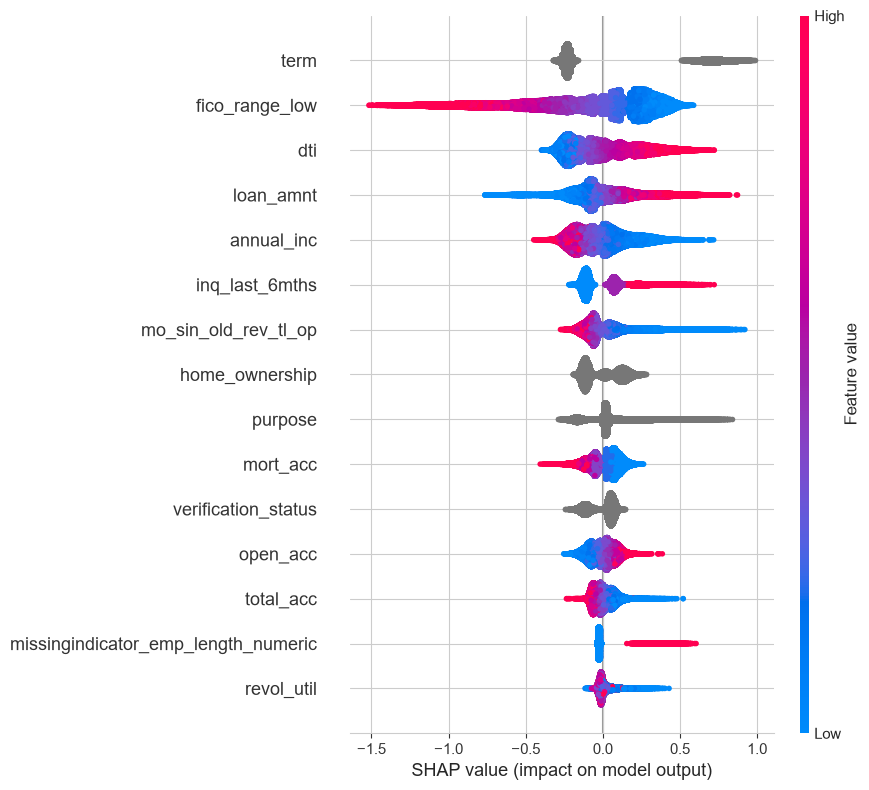

In [10]:
shap.summary_plot(avg_shap_values, X_test_transformed, feature_names=all_cols, max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 8)
plt.tight_layout()
plt.show()

Comparing averaged SHAP's global ranking (mean absolute SHAP value per
feature) to LightGBM's gain-based importance, averaged the same way across
the 5 fold models — same logic as notebook 04 sections 24-27, applied to
the ensemble.

In [11]:
gain_by_fold = pd.concat([
    pd.Series(est.named_steps['model'].feature_importances_,
              index=est.named_steps['model'].booster_.feature_name(), name=f'fold_{i}')
    for i, est in enumerate(fold_estimators)
], axis=1)
# fold 2 has no row for missingindicator_inq_last_6mths (see above) -- fill
# with 0 rather than skip, consistent with the SHAP averaging treatment.
gain_importance = (
    gain_by_fold.fillna(0).mean(axis=1).rename('gain_importance')
    .sort_values(ascending=False).reset_index().rename(columns={'index': 'feature'})
)

shap_importance = pd.DataFrame({
    'feature': all_cols,
    'mean_abs_shap': np.abs(avg_shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

comparison = gain_importance.head(10).merge(
    shap_importance.reset_index().rename(columns={'index': 'shap_rank'}),
    on='feature', how='left',
)
comparison['gain_rank'] = comparison.index
comparison[['feature', 'gain_rank', 'gain_importance', 'shap_rank', 'mean_abs_shap']]

,feature,gain_rank,gain_importance,shap_rank,mean_abs_shap
0,term,0,"279,736.53",0,0.35
1,fico_range_low,1,"156,030.80",1,0.32
2,dti,2,"79,705.65",2,0.18
3,mort_acc,3,"43,784.87",9,0.08
4,annual_inc,4,"41,815.23",4,0.14
5,loan_amnt,5,"34,567.56",3,0.16
6,mo_sin_old_rev_tl_op,6,"34,327.38",6,0.12
7,home_ownership,7,"31,955.24",7,0.11
8,inq_last_6mths,8,"30,599.88",5,0.12
9,purpose,9,"26,015.45",8,0.09


In [12]:
mort_acc_idx = all_cols.index('mort_acc')
mort_acc_corr = np.corrcoef(
    X_test_transformed['mort_acc'].astype(float), avg_shap_values[:, mort_acc_idx]
)[0, 1]
print(f'Correlation between mort_acc value and its averaged SHAP contribution: {mort_acc_corr:.2f}')
print('(negative = higher mort_acc pushes predicted risk down, i.e. protective)')

Correlation between mort_acc value and its averaged SHAP contribution: -0.91
(negative = higher mort_acc pushes predicted risk down, i.e. protective)


**Ranking is stable — essentially a match to notebook 04, as expected.**
`term`, `fico_range_low`, and `dti` still rank #1-#3 by both methods,
identically ordered. `mort_acc` reproduces notebook 04's exact
gain-vs-SHAP gap: **#3 by gain, #9 by mean |SHAP|** — the same two ranks as
the pre-calibration model, not just a similar pattern. Its value-vs-SHAP
correlation is **-0.91**, matching notebook 04's -0.91 to two decimal
places — more mortgage accounts is confirmed protective here too.

This stability is the expected result, not a coincidence: the 5 fold
models share the same architecture, hyperparameters, and (mostly) the same
training population as the single model notebook 04 explained, and
isotonic calibration — applied only after each fold's tree structure is
already fixed — has no mechanism to touch feature attribution. Finding
the ranking unchanged is confirmation the calibration step behaved exactly
as designed, not a new finding about what drives risk.

## 6. Notebook summary

- **Thresholds: essentially unchanged.** Cost-optimal stays at **0.10**,
  exactly matching notebook 04. F1-optimal reads 0.19 here vs. notebook 04's
  0.18 on the coarse 100-point grid — but a fine 2,000-point sweep (checked
  directly) shows both models' true optimum is the identical **0.1876**;
  the coarse-grid split is a rounding artifact of the small shift notebook
  03's garbage-value fix made to the base model, not a real effect of
  calibration. Both cutoffs sit in the middle of the distribution that
  notebook 04b found calibration reshapes only gently, which is why neither
  business-facing decision moved despite calibration materially changing
  the underlying probability values.
- **Phase 3 decision bands, finalized:** low risk below 0.10 (~6.9%
  observed default rate), review from 0.10 to 0.20 (~17.1%), high risk at
  0.20 and up (~33.0%). The 0.20 high-risk cutoff is a deliberate rounding
  of the F1-optimal sweep value (fine-grid 0.1876) for a cleaner
  business-facing number, not a precision tradeoff. 96.1% of loans land in
  the same band whether scored by the calibrated or uncalibrated model; the
  ~4% that move sit right at the boundaries, as expected from reshaping a
  continuous score around fixed cutoffs.
- **SHAP-driven feature story: stable, as expected for a monotonic
  transform.** `term`, `fico_range_low`, and `dti` remain the top three
  drivers by both gain and SHAP, identically ordered to notebook 04.
  `mort_acc` reproduces the exact same gain-vs-SHAP disagreement (#3 vs.
  #9) and the same protective direction (correlation -0.91) found
  pre-calibration — confirmation that isotonic calibration corrected *how
  confident* the model's scores are without changing *what* drives them.
- **This resolves the last open item before Phase 1 closes.** Every
  Phase 3-facing artifact — predicted probabilities, decision thresholds,
  and the feature-attribution story — is now derived from the same final
  calibrated pipeline (`models/lgbm_default_risk_calibrated.joblib`), with
  no analysis still hanging off the pre-calibration model. Phase 2
  (vintage/cohort survival analysis) starts next.